# **Import Library**

In [2]:
import os
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

# Setup Device CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Inference pipeline berjalan menggunakan: {device}")

# Definisikan mapping kelas sesuai urutan folder saat training
ROOT_CLASSES = ['inorganic', 'organic']
ORG_CLASSES = ['Food Organics', 'Vegetation']
INORG_CLASSES = ['Cardboard', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash']

# Gabungan seluruh kelas akhir (9 kelas asli) untuk evaluasi final
ALL_FINAL_CLASSES = sorted(ORG_CLASSES + INORG_CLASSES)
print(f"Total kelas akhir yang akan dievaluasi: {ALL_FINAL_CLASSES}")

Inference pipeline berjalan menggunakan: cuda
Total kelas akhir yang akan dievaluasi: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


# **Memuat 3 Model**

In [3]:
print("Memuat arsitektur dan bobot model...")

# 1. Load Root Model (ViT)
model_root = models.vit_b_16()
model_root.heads.head = nn.Linear(model_root.heads.head.in_features, len(ROOT_CLASSES))
model_root.load_state_dict(torch.load("../saved_models/root_model_best.pth", map_location=device))
model_root = model_root.to(device).eval()

# 2. Load Sub-Model Organik (MobileNetV3)
model_organic = models.mobilenet_v3_large()
model_organic.classifier[3] = nn.Linear(model_organic.classifier[3].in_features, len(ORG_CLASSES))
model_organic.load_state_dict(torch.load("../saved_models/sub_organic_best.pth", map_location=device))
model_organic = model_organic.to(device).eval()

# 3. Load Sub-Model Anorganik (ConvNeXt-Tiny)
model_inorganic = models.convnext_tiny()
model_inorganic.classifier[2] = nn.Linear(model_inorganic.classifier[2].in_features, len(INORG_CLASSES))
model_inorganic.load_state_dict(torch.load("../saved_models/sub_inorganic_best.pth", map_location=device))
model_inorganic = model_inorganic.to(device).eval()

print("Semua model berhasil dimuat dan diset ke mode evaluasi (eval)!")

Memuat arsitektur dan bobot model...


C:\Users\Rafif Fikri\AppData\Local\Temp\ipykernel_40056\2549436724.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_root.load_state_dict(torch.load("../saved_models

Semua model berhasil dimuat dan diset ke mode evaluasi (eval)!


# **Inference 1 Gambar Acak**

In [5]:
TEST_DIR = "../data/processed/level_2_sub" 

test_image_paths = []
test_true_labels = []

# Scan cabang organik
for root, dirs, files in os.walk(os.path.join(TEST_DIR, "organic_branch", "test")):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_image_paths.append(os.path.join(root, file))
            test_true_labels.append(os.path.basename(root))

# Scan cabang anorganik
for root, dirs, files in os.walk(os.path.join(TEST_DIR, "inorganic_branch", "test")):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            test_image_paths.append(os.path.join(root, file))
            test_true_labels.append(os.path.basename(root))

total_data = len(test_image_paths)
print(f"Total seluruh data test yang ditemukan: {total_data} gambar.")

# --- DEFINISIKAN TRANSFORMASI DI SINI AGAR TIDAK NAMEERROR ---
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if total_data == 0:
    print("[PERINGATAN] Data test tidak ditemukan! Periksa kembali path folder kamu.")
else:
    # List untuk menampung prediksi akhir dari pipeline hirarki kita
    test_predicted_labels = []

    print("\nMenjalankan evaluasi massal pada seluruh data test...")
    
    counter = 0

    # Jalankan flat loop dengan tqdm
    for img_path in tqdm(test_image_paths, desc="Inference Progress"):
        # Load gambar memakai PIL
        img = Image.open(img_path).convert('RGB')
        
        # Sekarang test_transform sudah pasti terdefinisi di atas
        input_tensor = test_transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            # Langkah 1: Prediksi tingkat Root (Organik vs Anorganik)
            out_root = model_root(input_tensor)
            _, pred_root_idx = torch.max(out_root, 1)
            pred_root_str = ROOT_CLASSES[pred_root_idx.item()]
            
            # Langkah 2: Teruskan ke Sub-Model berdasarkan hasil Root
            if pred_root_str == 'organic':
                out_sub = model_organic(input_tensor)
                _, pred_sub_idx = torch.max(out_sub, 1)
                final_pred_str = ORG_CLASSES[pred_sub_idx.item()]
            else:
                out_sub = model_inorganic(input_tensor)
                _, pred_sub_idx = torch.max(out_sub, 1)
                final_pred_str = ININORG_CLASSES[pred_sub_idx.item()] if 'ININORG_CLASSES' in globals() else INORG_CLASSES[pred_sub_idx.item()]
                
        test_predicted_labels.append(final_pred_str)
        
        counter += 1
        if counter % 50 == 0 or counter == total_data:
            print(f"  [STATUS] Berhasil memproses {counter}/{total_data} gambar...")

    print("\n[SUKSES] Inference selesai untuk seluruh data test!")

Total seluruh data test yang ditemukan: 908 gambar.

Menjalankan evaluasi massal pada seluruh data test...


Inference Progress:   0%|          | 0/908 [00:00<?, ?it/s]

  [STATUS] Berhasil memproses 50/908 gambar...
  [STATUS] Berhasil memproses 100/908 gambar...
  [STATUS] Berhasil memproses 150/908 gambar...
  [STATUS] Berhasil memproses 200/908 gambar...
  [STATUS] Berhasil memproses 250/908 gambar...
  [STATUS] Berhasil memproses 300/908 gambar...
  [STATUS] Berhasil memproses 350/908 gambar...
  [STATUS] Berhasil memproses 400/908 gambar...
  [STATUS] Berhasil memproses 450/908 gambar...
  [STATUS] Berhasil memproses 500/908 gambar...
  [STATUS] Berhasil memproses 550/908 gambar...
  [STATUS] Berhasil memproses 600/908 gambar...
  [STATUS] Berhasil memproses 650/908 gambar...
  [STATUS] Berhasil memproses 700/908 gambar...
  [STATUS] Berhasil memproses 750/908 gambar...
  [STATUS] Berhasil memproses 800/908 gambar...
  [STATUS] Berhasil memproses 850/908 gambar...
  [STATUS] Berhasil memproses 900/908 gambar...
  [STATUS] Berhasil memproses 908/908 gambar...

[SUKSES] Inference selesai untuk seluruh data test!


# **Confussion Matrix Hirarki**


==================== HIERARCHICAL SYSTEM REPORT (9 CLASSES) ====================
                     precision    recall  f1-score   support

          Cardboard       1.00      0.99      0.99        87
      Food Organics       1.00      0.97      0.99        78
              Glass       0.99      1.00      0.99        80
              Metal       0.99      0.99      0.99       150
Miscellaneous Trash       0.99      0.99      0.99        93
              Paper       1.00      1.00      1.00        95
            Plastic       0.99      0.99      0.99       177
      Textile Trash       0.98      1.00      0.99        62
         Vegetation       0.98      1.00      0.99        86

           accuracy                           0.99       908
          macro avg       0.99      0.99      0.99       908
       weighted avg       0.99      0.99      0.99       908



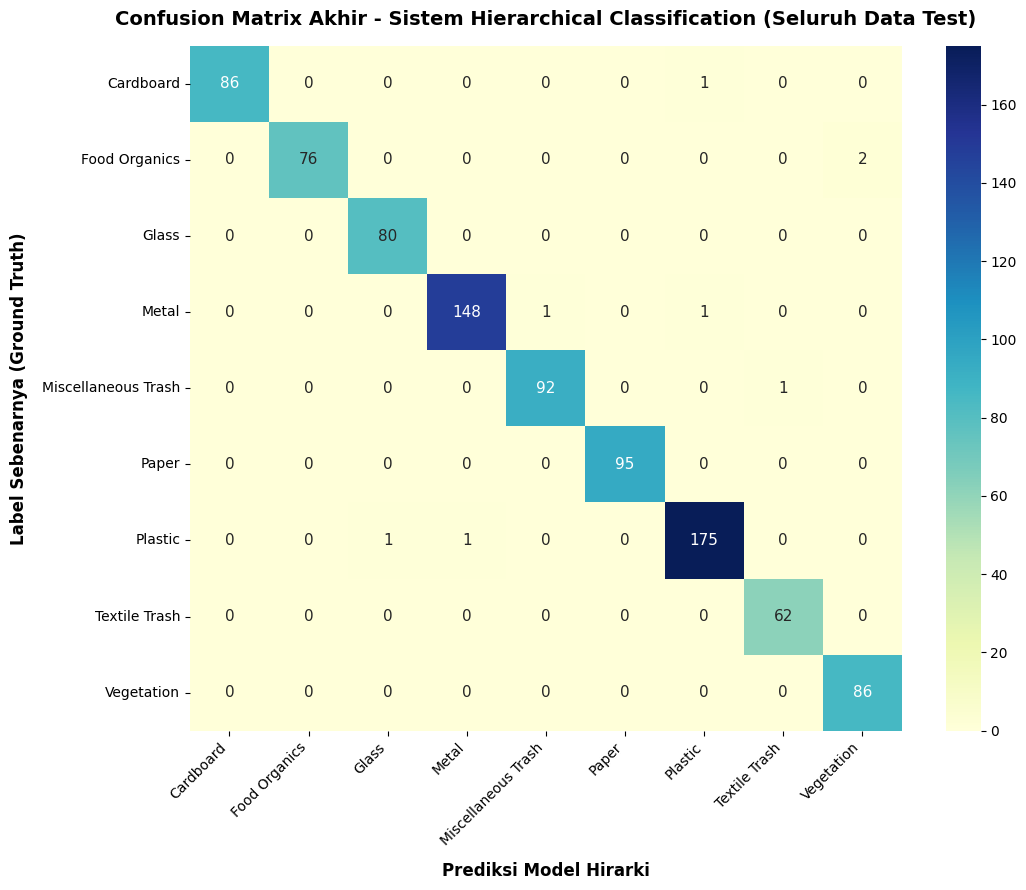

In [ ]:
# 1. Tampilkan Classification Report resmi (Precision, Recall, F1-Score per kelas)
print("\n" + "="*20 + " HIERARCHICAL SYSTEM REPORT (9 CLASSES) " + "="*20)
print(classification_report(test_true_labels, test_predicted_labels, target_names=ALL_FINAL_CLASSES))

# 2. Hitung Confusion Matrix Akhir
cm_final = confusion_matrix(test_true_labels, test_predicted_labels, labels=ALL_FINAL_CLASSES)

# 3. Visualisasikan menggunakan Heatmap Seaborn agar rapi dimasukkan ke laporan
plt.figure(figsize=(11, 9))
sns.heatmap(
    cm_final, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu', 
    xticklabels=ALL_FINAL_CLASSES, 
    yticklabels=ALL_FINAL_CLASSES,
    annot_kws={"size": 11}
)

plt.title('Confusion Matrix Akhir - Sistem Hierarchical Classification (Seluruh Data Test)', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Prediksi Model Hirarki', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Label Sebenarnya (Ground Truth)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Simpan grafik otomatis ke folder reports
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/05_final_hierarchical_system_matrix.png", dpi=300)
plt.show()

# **Prediksi Gambar Benar dan Salah**

### **Kelompokkan Gambar**

In [ ]:
correct_indices = [i for i, (true, pred) in enumerate(zip(test_true_labels, test_predicted_labels)) if true == pred]
incorrect_indices = [i for i, (true, pred) in enumerate(zip(test_true_labels, test_predicted_labels)) if true != pred]

print(f"Total Prediksi Benar: {len(correct_indices)} gambar")
print(f"Total Prediksi Salah : {len(incorrect_indices)} gambar")

# Ambil sampel acak (maksimal 4 gambar untuk masing-masing kategori)
sample_size = min(4, len(correct_indices), len(incorrect_indices))
sampled_correct = random.sample(correct_indices, sample_size)
sampled_incorrect = random.sample(incorrect_indices, sample_size)

Total Prediksi Benar: 900 gambar
Total Prediksi Salah : 8 gambar


### **Prediksi Benar**

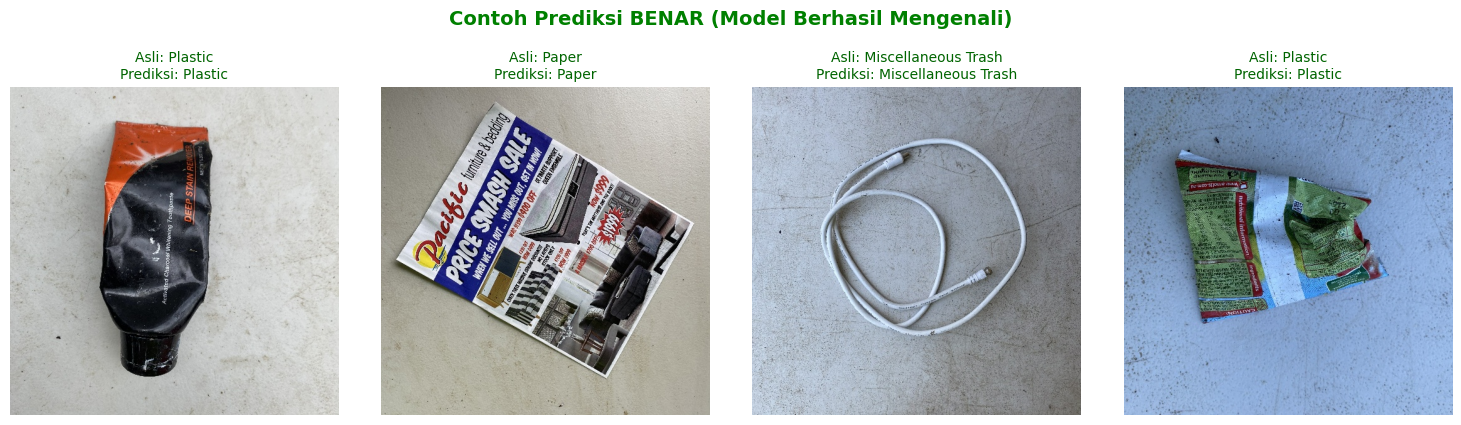

In [ ]:
if len(sampled_correct) > 0:
    fig, axes = plt.subplots(1, sample_size, figsize=(15, 4))
    if sample_size == 1: axes = [axes] # Jaga agar tetap berbentuk list jika hanya 1 sampel
    
    fig.suptitle('Contoh Prediksi BENAR (Model Berhasil Mengenali)', fontsize=14, fontweight='bold', color='green', y=1.05)
    
    for idx, test_idx in enumerate(sampled_correct):
        img_path = test_image_paths[test_idx]
        orig_img = Image.open(img_path).convert('RGB')
        
        axes[idx].imshow(orig_img)
        axes[idx].set_title(f"Asli: {test_true_labels[test_idx]}\nPrediksi: {test_predicted_labels[test_idx]}", fontsize=10, color='darkgreen')
        axes[idx].axis('off')
    plt.tight_layout()
    plt.savefig("../reports/figures/06_sampel_prediksi_benar.png", dpi=300, bbox_inches='tight')
    plt.show()

### **Prediksi Salah**

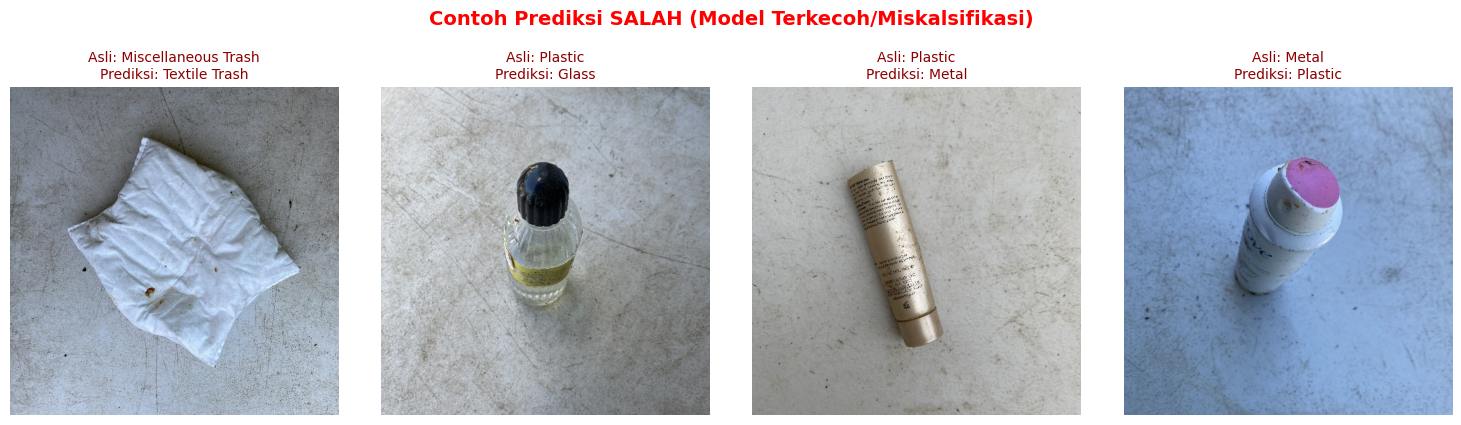

In [ ]:
if len(sampled_incorrect) > 0:
    fig, axes = plt.subplots(1, sample_size, figsize=(15, 4))
    if sample_size == 1: axes = [axes]
    
    fig.suptitle('Contoh Prediksi SALAH (Model Terkecoh/Miskalsifikasi)', fontsize=14, fontweight='bold', color='red', y=1.05)
    
    for idx, test_idx in enumerate(sampled_incorrect):
        img_path = test_image_paths[test_idx]
        orig_img = Image.open(img_path).convert('RGB')
        
        axes[idx].imshow(orig_img)
        # Warnai merah untuk menunjukkan letak kesalahan model
        axes[idx].set_title(f"Asli: {test_true_labels[test_idx]}\nPrediksi: {test_predicted_labels[test_idx]}", fontsize=10, color='darkred')
        axes[idx].axis('off')
    plt.tight_layout()
    plt.savefig("../reports/figures/07_sampel_prediksi_salah.png", dpi=300, bbox_inches='tight')
    plt.show()